# Swiss Snow Quality — Exploratory Data Analysis

Data sources:
- **MeteoSwiss OGD** — daily station observations (75 alpine stations, ≥800m)
- **Open-Meteo Archive** — ERA5 reanalysis (snowfall, snow depth, precip)

Target variable: **powder probability** (binary) — defined as fresh dry snow conditions.

In [1]:
import sys
sys.path.insert(0, './')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)

## 1. Load MeteoSwiss daily data

In [2]:
df = pd.read_parquet('data/raw/meteoswiss_daily_recent.parquet')
print(f'Shape: {df.shape}')
print(f'Stations: {df["station_id"].nunique()}')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')
df.head()

Shape: (4147, 46)
Stations: 75
Date range: 2025-01-01 → 2026-02-23


,station_abbr,date,tre200d0,tre200dx,tre200dn,tre005d0,tre005dx,tre005dn,ure200d0,pva200d0,prestad0,pp0qffd0,ppz850d0,ppz700d0,pp0qnhd0,fkl010d0,fkl010d1,fu3010d0,fu3010d1,fkl010d3,...,oli000d0,olo000d0,osr000d0,ods000d0,sre000d0,sremaxdv,erefaod0,xcd000d0,dkl010d0,xno000d0,xno012d0,rreetsd0,tso005d0,tso010d0,tso020d0,station_id,altitude,lat,lon,name
0,ABO,2026-01-01,-1.50,7.20,-6.60,-3.70,7.80,-10.00,41.00,2.20,860.70,NaN,1425.00,NaN,1009.70,2.10,12.50,7.60,45.00,12.00,...,NaN,NaN,NaN,19.00,333.00,100.00,0.90,0.00,210.00,21.50,13.50,-0.60,NaN,NaN,NaN,ABO,1321.00,46.49,7.56,Adelboden
1,ABO,2026-01-02,-3.10,1.30,-6.10,-4.00,1.20,-8.80,67.40,3.20,855.20,NaN,1374.30,NaN,1003.50,2.60,10.90,9.40,39.20,10.40,...,NaN,NaN,NaN,30.00,80.00,24.00,0.70,0.00,192.00,23.10,15.10,-0.10,NaN,NaN,NaN,ABO,1321.00,46.49,7.56,Adelboden
2,ABO,2026-01-03,-5.40,-2.40,-8.30,-4.90,1.60,-8.40,84.80,3.40,855.70,NaN,1378.40,NaN,1004.10,2.00,9.70,7.20,34.90,9.30,...,NaN,NaN,NaN,39.00,110.00,33.00,0.20,0.00,84.00,25.40,17.40,-0.10,NaN,NaN,NaN,ABO,1321.00,46.49,7.56,Adelboden
3,ABO,2026-01-04,-9.50,-4.50,-12.40,-10.90,-0.80,-15.40,63.30,1.90,857.50,NaN,1393.50,NaN,1006.10,0.90,4.60,3.20,16.60,4.40,...,NaN,NaN,NaN,15.00,336.00,100.00,0.10,0.00,166.00,29.50,21.50,-0.40,NaN,NaN,NaN,ABO,1321.00,46.49,7.56,Adelboden
4,ABO,2026-01-05,-10.70,-6.30,-13.70,-12.30,-2.40,-16.40,57.00,1.50,858.00,NaN,1397.50,NaN,1006.60,1.00,4.40,3.60,15.80,4.10,...,NaN,NaN,NaN,15.00,336.00,100.00,0.20,0.00,117.00,30.70,22.70,-0.40,NaN,NaN,NaN,ABO,1321.00,46.49,7.56,Adelboden


In [3]:
# Overview of column availability
snow_cols = ['htoautd0', 'tre200d0', 'tre200dx', 'tre200dn',
             'rre150d0', 'ure200d0', 'fkl010d0', 'sre000d0']
availability = df[snow_cols].notna().mean().rename('fill_rate')
print(availability.to_string())

htoautd0   0.42
tre200d0   0.97
tre200dx   0.97
tre200dn   0.97
rre150d0   0.84
ure200d0   0.97
fkl010d0   0.96
sre000d0   0.87


## 2. Station overview — altitude distribution

In [4]:
stations = df.groupby('station_id').agg(
    altitude=('altitude', 'first'),
    lat=('lat', 'first'),
    lon=('lon', 'first'),
    name=('name', 'first'),
    snow_fill=('htoautd0', lambda x: x.notna().mean()),
    mean_snow_cm=('htoautd0', 'mean'),
    max_snow_cm=('htoautd0', 'max'),
).reset_index().sort_values('altitude', ascending=False)

print(f'{len(stations)} alpine stations')
stations.head(15)

75 alpine stations


,station_id,altitude,lat,lon,name,snow_fill,mean_snow_cm,max_snow_cm
41,JUN,3571.00,46.55,7.99,Jungfraujoch,0.00,NaN,NaN
21,COV,3294.00,46.42,9.82,Piz Corvatsch,0.00,NaN,NaN
34,GOR,3129.00,45.98,7.79,Gornergrat,0.00,NaN,NaN
66,TIT,3045.00,46.77,8.43,Titlis,0.00,NaN,NaN
23,DIA,2964.00,46.33,7.20,Les Diablerets,0.00,NaN,NaN
26,EGH,2892.00,46.43,8.09,Eggishorn,0.00,NaN,NaN
4,ATT,2734.00,46.10,7.27,Les Attelas,0.00,NaN,NaN
73,WFJ,2691.00,46.83,9.81,Weissfluhjoch,0.00,NaN,NaN
56,PMA,2668.00,46.58,9.53,Piz Martegnas,0.00,NaN,NaN
59,SAE,2501.00,47.25,9.34,Säntis,0.00,NaN,NaN


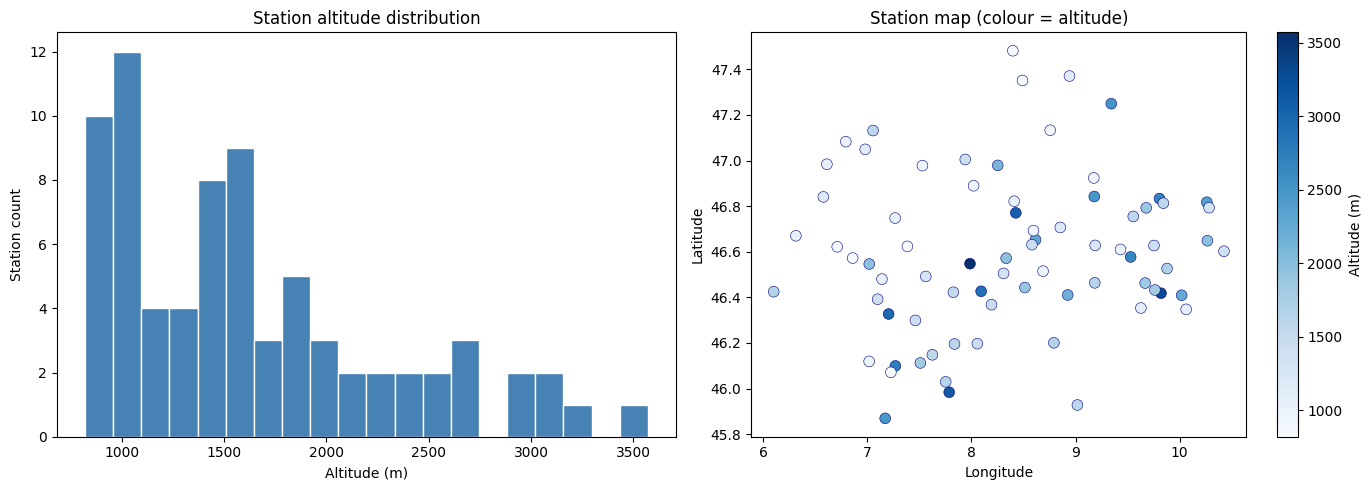

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(stations['altitude'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Altitude (m)')
axes[0].set_ylabel('Station count')
axes[0].set_title('Station altitude distribution')

sc = axes[1].scatter(
    stations['lon'], stations['lat'],
    c=stations['altitude'], cmap='Blues', s=60, edgecolors='navy', linewidths=0.4
)
plt.colorbar(sc, ax=axes[1], label='Altitude (m)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Station map (colour = altitude)')
plt.tight_layout()
plt.show()

## 3. Snow depth — temporal patterns

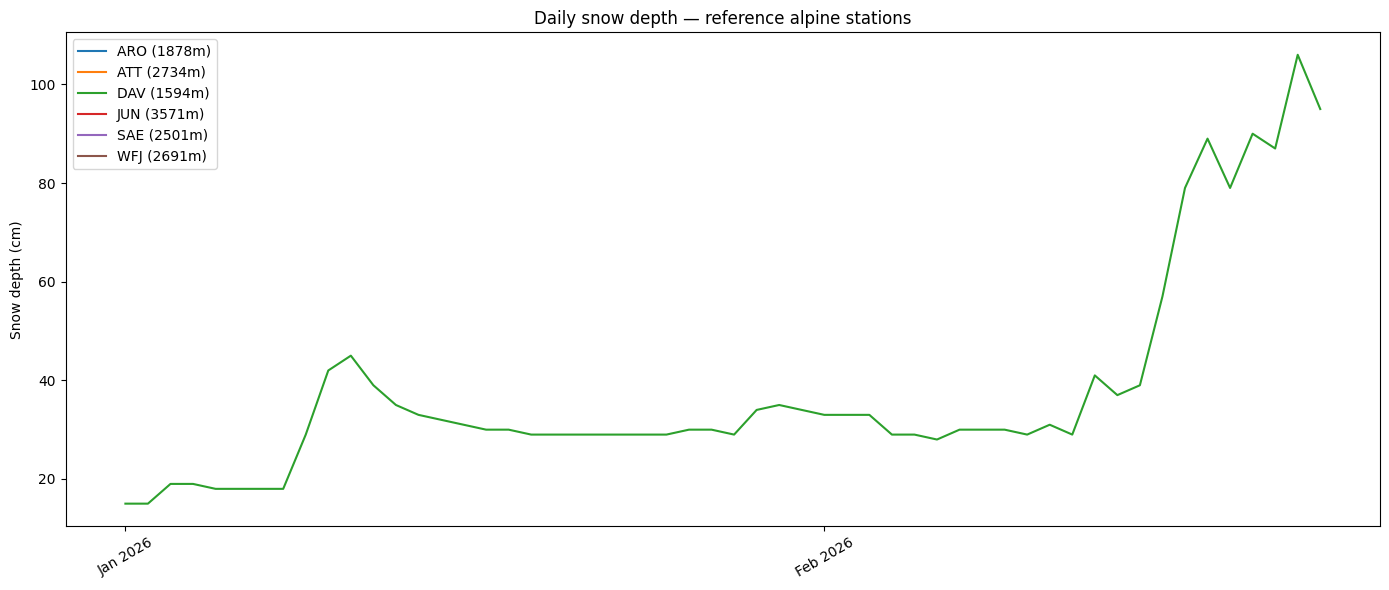

In [6]:
# Pick a few high-altitude reference stations
reference_stations = ['JUN', 'SAE', 'WFJ', 'DAV', 'ARO', 'ATT']
ref = df[df['station_id'].isin(reference_stations)].copy()

fig, ax = plt.subplots(figsize=(14, 6))
for sid, grp in ref.groupby('station_id'):
    grp_sorted = grp.sort_values('date')
    alt = grp_sorted['altitude'].iloc[0]
    ax.plot(grp_sorted['date'], grp_sorted['htoautd0'],
            label=f'{sid} ({alt:.0f}m)', linewidth=1.5)

ax.set_ylabel('Snow depth (cm)')
ax.set_title('Daily snow depth — reference alpine stations')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.legend(loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 4. Define target variable: Powder Probability

A day qualifies as **powder** if:
1. Snow depth increased by ≥5cm vs previous day (fresh snowfall)
2. Mean temperature ≤ -2°C (cold = dry snow, not wet/slushy)
3. No rain in previous 48h (no rain-on-snow crust)

In [7]:
def compute_powder_label(grp: pd.DataFrame) -> pd.DataFrame:
    """Compute powder binary label per station group."""
    g = grp.sort_values('date').copy()

    g['snow_delta'] = g['htoautd0'].diff()           # cm gained since yesterday
    # fillna(0): missing precip treated as no rain (conservative assumption)
    g['rain_48h'] = g['rre150d0'].fillna(0).rolling(2).sum()

    # Powder: fresh snow + cold + no recent rain + have actual snow depth data
    g['is_powder'] = (
        g['snow_delta'].notna() &
        (g['snow_delta'] >= 5) &
        (g['tre200d0'] <= -2) &
        (g['rain_48h'] < 1)
    ).astype(int)

    return g

df = df.groupby('station_id', group_keys=False).apply(compute_powder_label)
print('Powder label distribution:')
vc = df['is_powder'].value_counts(normalize=True)
vc.index = vc.index.map({0: 'non-powder', 1: 'powder'})
print(vc)
print(f'\nTotal powder station-days: {df["is_powder"].sum()}')

Powder label distribution:
is_powder
non-powder   1.00
Name: proportion, dtype: float64

Total powder station-days: 0


/tmp/ipykernel_78529/3549255549.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('station_id', group_keys=False).apply(compute_powder_label)


In [8]:
# Powder days per station — top 20
powder_by_station = (
    df.groupby('station_id')
    .agg(powder_days=('is_powder', 'sum'),
         total_days=('is_powder', 'count'),
         altitude=('altitude', 'first'),
         name=('name', 'first'))
    .assign(powder_pct=lambda x: 100 * x['powder_days'] / x['total_days'])
    .sort_values('powder_pct', ascending=False)
)
print(powder_by_station.head(20).to_string())

            powder_days  total_days  altitude                  name  powder_pct
station_id                                                                     
ABO                   0          54   1321.00             Adelboden        0.00
AND                   0          54    987.00                Andeer        0.00
ANT                   0          54   1435.00             Andermatt        0.00
ARO                   0          54   1878.00                 Arosa        0.00
ATT                   0          54   2734.00           Les Attelas        0.00
BAN                   0          54    942.00              Bantiger        0.00
BEH                   0          54   2260.00     Passo del Bernina        0.00
BIN                   0          54   1479.00                  Binn        0.00
BIV                   0          54   1856.00                 Bivio        0.00
BLA                   0         151   1538.00  Blatten, Lötschental        0.00
BOL                   0          54    8

## 5. Feature Engineering

In [9]:
def engineer_features(grp: pd.DataFrame) -> pd.DataFrame:
    g = grp.sort_values('date').copy()

    # Temperature rolling stats
    g['temp_mean_3d']  = g['tre200d0'].rolling(3).mean()
    g['temp_mean_7d']  = g['tre200d0'].rolling(7).mean()
    g['temp_delta_3d'] = g['tre200d0'] - g['tre200d0'].shift(3)  # warming trend

    # Precipitation rolling
    g['precip_7d'] = g['rre150d0'].rolling(7).sum()

    # Days since last significant snowfall (delta ≥ 5cm)
    is_snowfall = g['snow_delta'].fillna(0) >= 5
    days_counter = []
    count = 999
    for flag in is_snowfall:
        count = 0 if flag else count + 1
        days_counter.append(count)
    g['days_since_snowfall'] = days_counter

    # Seasonal encoding
    doy = g['date'].dt.dayofyear
    g['doy_sin'] = np.sin(2 * np.pi * doy / 365)
    g['doy_cos'] = np.cos(2 * np.pi * doy / 365)

    # Altitude (already present, kept as-is)
    return g

df = df.groupby('station_id', group_keys=False).apply(engineer_features)
print('Feature columns:')
feature_cols = ['temp_mean_3d', 'temp_mean_7d', 'temp_delta_3d',
                'precip_7d', 'days_since_snowfall', 'doy_sin', 'doy_cos',
                'altitude', 'snow_delta', 'rain_48h',
                'ure200d0', 'fkl010d0', 'sre000d0']
print(df[feature_cols].describe().T)

Feature columns:
                      count    mean    std    min     25%     50%     75%  \
temp_mean_3d        3893.00   -2.77   4.85 -21.50   -5.87   -1.93    0.60   
temp_mean_7d        3601.00   -2.63   4.48 -18.93   -5.66   -1.84    0.59   
temp_delta_3d       3820.00    0.44   3.73 -21.60   -1.90    0.20    2.20   
precip_7d           3121.00   21.68  29.88   0.00    2.30   10.30   29.30   
days_since_snowfall 4147.00  672.33 484.08   0.00   11.00 1009.00 1030.00   
doy_sin             4147.00    0.45   0.24   0.02    0.24    0.46    0.66   
doy_cos             4147.00    0.83   0.21  -0.86    0.75    0.89    0.97   
altitude            4147.00 1632.50 665.50 820.00 1050.00 1538.00 1971.00   
snow_delta          1726.00    0.56   5.66 -28.00   -1.00    0.00    0.00   
rain_48h            4072.00    5.10  10.90   0.00    0.00    0.20    5.10   
ure200d0            4039.00   74.91  16.58  11.40   63.30   77.90   88.50   
fkl010d0            3982.00    3.34   2.84   0.20    1.30  

/tmp/ipykernel_78529/861296346.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('station_id', group_keys=False).apply(engineer_features)


## 6. Correlation with powder label

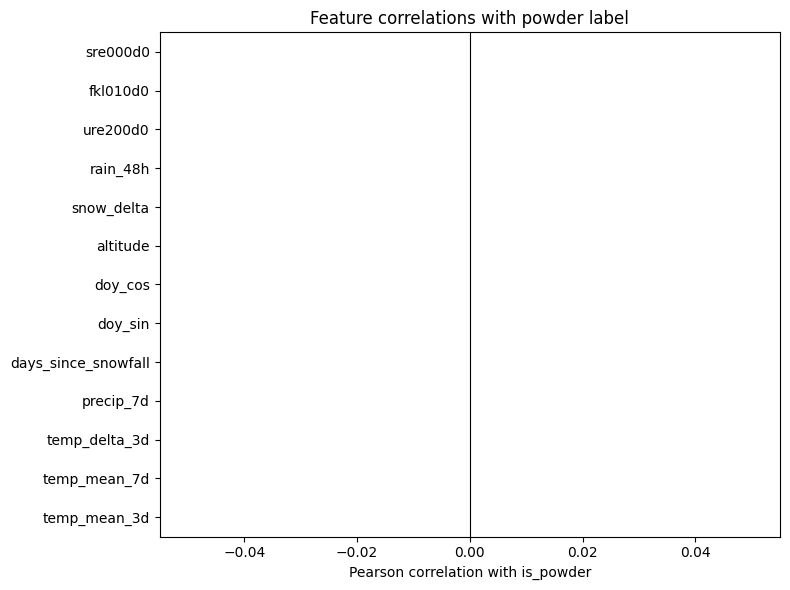

In [10]:
corr = df[feature_cols + ['is_powder']].corr()['is_powder'].drop('is_powder').sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#d73027' if v < 0 else '#4575b4' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with is_powder')
ax.set_title('Feature correlations with powder label')
plt.tight_layout()
plt.show()

## 7. Save processed dataset

In [11]:
out_cols = ['station_id', 'name', 'date', 'lat', 'lon', 'altitude',
            'htoautd0', 'is_powder'] + feature_cols
# deduplicate while preserving order
seen, unique_cols = set(), []
for c in out_cols:
    if c not in seen:
        seen.add(c)
        unique_cols.append(c)

df_out = df[[c for c in unique_cols if c in df.columns]].copy()
df_out.to_parquet('data/processed/features_recent.parquet', index=False)
print(f'Saved {len(df_out)} rows to data/processed/features_recent.parquet')
df_out.head()

Saved 4147 rows to data/processed/features_recent.parquet


,station_id,name,date,lat,lon,altitude,htoautd0,is_powder,temp_mean_3d,temp_mean_7d,temp_delta_3d,precip_7d,days_since_snowfall,doy_sin,doy_cos,snow_delta,rain_48h,ure200d0,fkl010d0,sre000d0
0,ABO,Adelboden,2026-01-01,46.49,7.56,1321.00,3.00,0,NaN,NaN,NaN,NaN,1000,0.02,1.00,NaN,NaN,41.00,2.10,333.00
1,ABO,Adelboden,2026-01-02,46.49,7.56,1321.00,3.00,0,NaN,NaN,NaN,NaN,1001,0.03,1.00,0.00,0.00,67.40,2.60,80.00
2,ABO,Adelboden,2026-01-03,46.49,7.56,1321.00,3.00,0,-3.33,NaN,NaN,NaN,1002,0.05,1.00,0.00,0.00,84.80,2.00,110.00
3,ABO,Adelboden,2026-01-04,46.49,7.56,1321.00,3.00,0,-6.00,NaN,-8.00,NaN,1003,0.07,1.00,0.00,0.00,63.30,0.90,336.00
4,ABO,Adelboden,2026-01-05,46.49,7.56,1321.00,3.00,0,-8.53,NaN,-7.60,NaN,1004,0.09,1.00,0.00,0.00,57.00,1.00,336.00
